# Data Discovery

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
import rasterio
import torch
from torch.utils.data import Dataset, DataLoader

In [2]:
class WaterDataset(Dataset):
    def __init__(self, image_dir, label_dir, transform=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.tif")), key=lambda x: int(os.path.basename(x).split(".")[0]))
        self.label_paths = sorted(glob(os.path.join(label_dir, "*.png")), key=lambda x: int(os.path.basename(x).split(".")[0]))
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        # Load multispectral image
        with rasterio.open(self.image_paths[idx]) as src:
            img = src.read()  # shape: (bands, H, W)
        
        # Load label
        label = np.array(Image.open(self.label_paths[idx]))  # shape: (H, W)
        
        if self.transform:
            img, label = self.transform(img, label)
        
        return torch.tensor(img, dtype=torch.float32), torch.tensor(label, dtype=torch.long)

In [3]:
data_dir = "/kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data"
image_dir = os.path.join(data_dir, "images")
label_dir = os.path.join(data_dir, "labels")

dataset = WaterDataset(image_dir, label_dir)

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


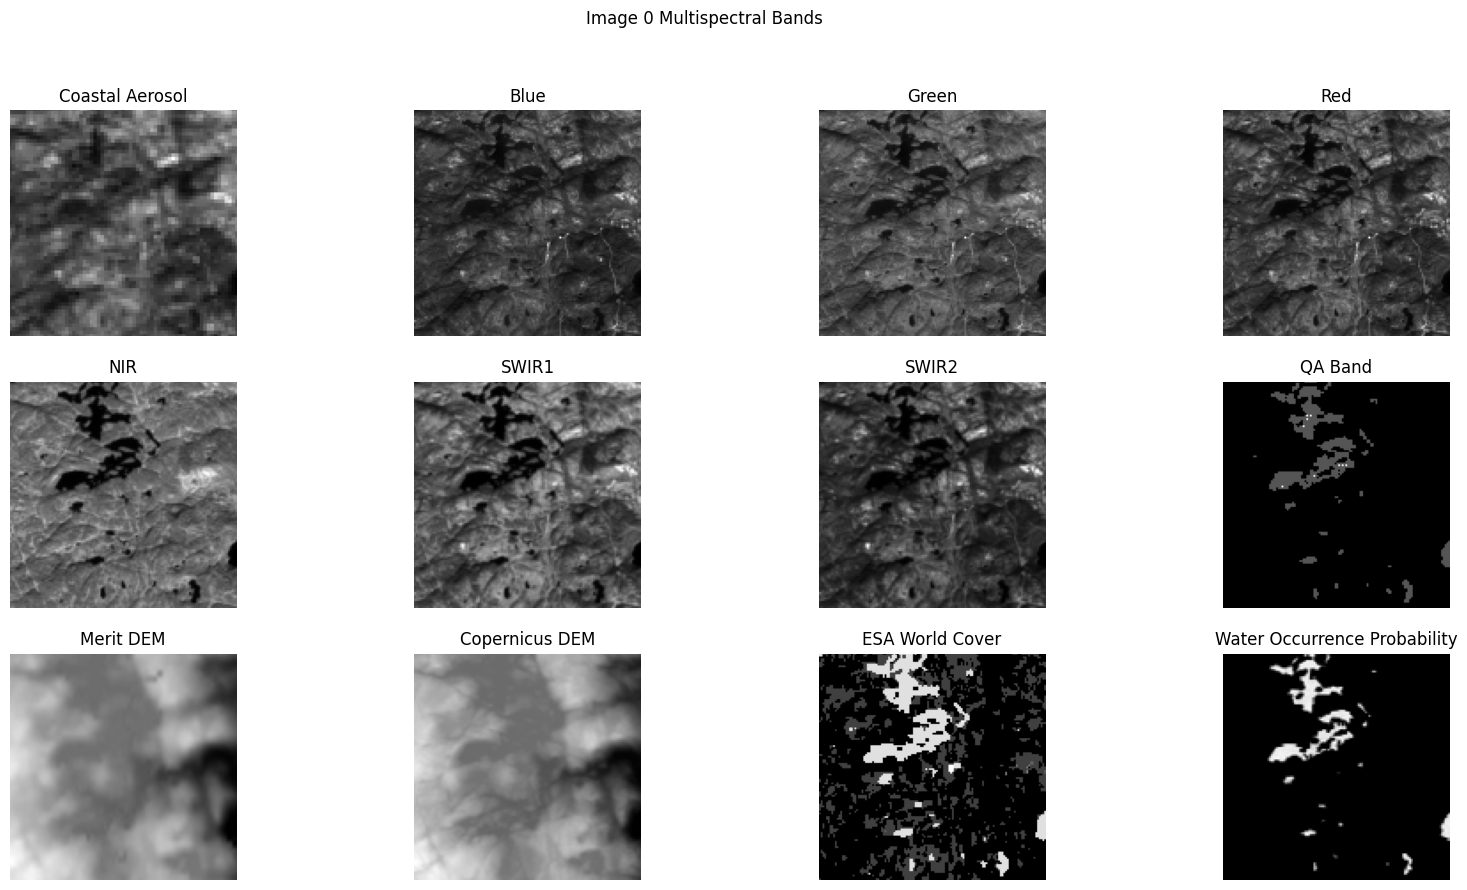

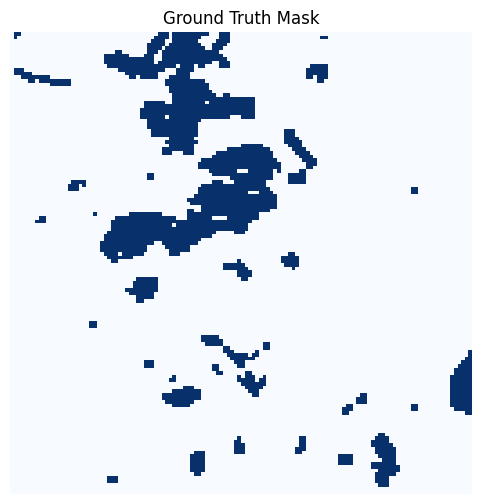

In [4]:
def plot_multispectral_bands(img, title=""):
    bands_names = [
        "Coastal Aerosol", "Blue", "Green", "Red", "NIR",
        "SWIR1", "SWIR2", "QA Band", "Merit DEM",
        "Copernicus DEM", "ESA World Cover", "Water Occurrence Probability"
    ]
    
    n_bands = img.shape[0]
    plt.figure(figsize=(20, 10))
    for i in range(n_bands):
        plt.subplot(3, 4, i+1)
        plt.imshow(img[i], cmap='gray')
        plt.title(bands_names[i])
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

# Example visualization for the first sample
img, label = dataset[0]
plot_multispectral_bands(img.numpy(), title="Image 0 Multispectral Bands")

plt.figure(figsize=(6,6))
plt.imshow(label.numpy(), cmap='Blues')
plt.title("Ground Truth Mask")
plt.axis('off')
plt.show()


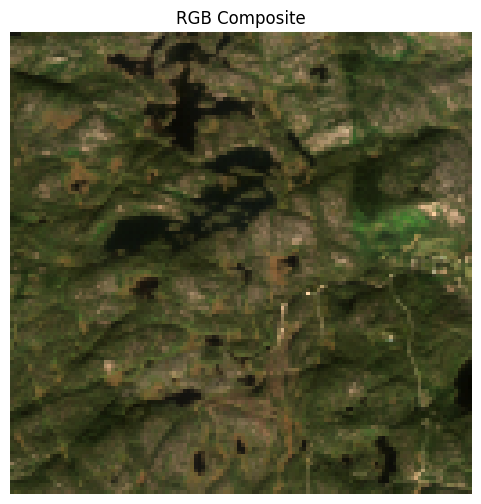

In [5]:
def plot_rgb_only(img):
    """
    Display RGB composite from multispectral image.
    Uses Red, Green, Blue bands (indices 3, 2, 1).
    """
    rgb = np.stack([img[3], img[2], img[1]], axis=-1)
    
    # Normalize for visualization
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.title("RGB Composite")
    plt.axis('off')
    plt.show()

# Example for first image
img, _ = dataset[0]
plot_rgb_only(img.numpy())

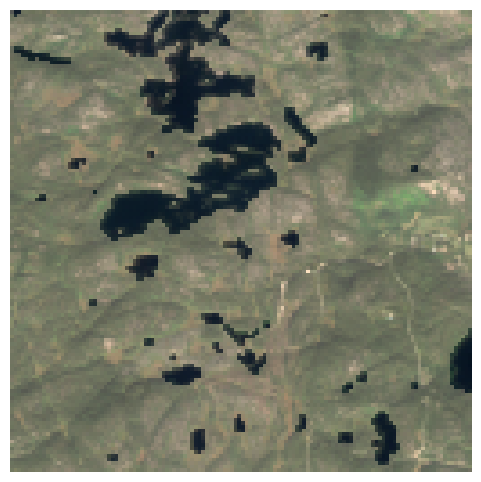

In [6]:
def plot_rgb(img, label=None):
    rgb = np.stack([img[3], img[2], img[1]], axis=-1)
    
    # Normalize for visualization
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min())
    
    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    if label is not None:
        plt.imshow(label, cmap='Blues', alpha=0.3)  # overlay mask
    plt.axis('off')
    plt.show()

plot_rgb(img.numpy(), label.numpy())

In [7]:
import os
import numpy as np
import torch
import rasterio
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [8]:
class WaterDataset(Dataset):
    def __init__(self, images_dir, labels_dir, normalize=True):
        self.images_dir = images_dir
        self.labels_dir = labels_dir
        
        self.image_files = sorted(os.listdir(images_dir))
        self.label_files = sorted(os.listdir(labels_dir))
        
        self.normalize = normalize

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        
        # ----- Load Multispectral Image -----
        image_path = os.path.join(self.images_dir, self.image_files[idx])
        
        with rasterio.open(image_path) as src:
            image = src.read()  # shape: (12, 128, 128)
        
        image = image.astype(np.float32)
        
        # ----- Normalize per band -----
        if self.normalize:
            for c in range(image.shape[0]):
                band = image[c]
                min_val = band.min()
                max_val = band.max()
                if max_val - min_val > 0:
                    image[c] = (band - min_val) / (max_val - min_val)

        # ----- Load Mask -----
        label_path = os.path.join(self.labels_dir, self.label_files[idx])
        label = np.array(Image.open(label_path))
        
        # Ensure binary
        label = (label > 0).astype(np.float32)

        return torch.tensor(image), torch.tensor(label).unsqueeze(0)

In [9]:
data_path = "/kaggle/input/datasets/mennaezzelarab/water-segmentation-dataset/data"

images_dir = os.path.join(data_path, "images")
labels_dir = os.path.join(data_path, "labels")

dataset = WaterDataset(images_dir, labels_dir, normalize=True)

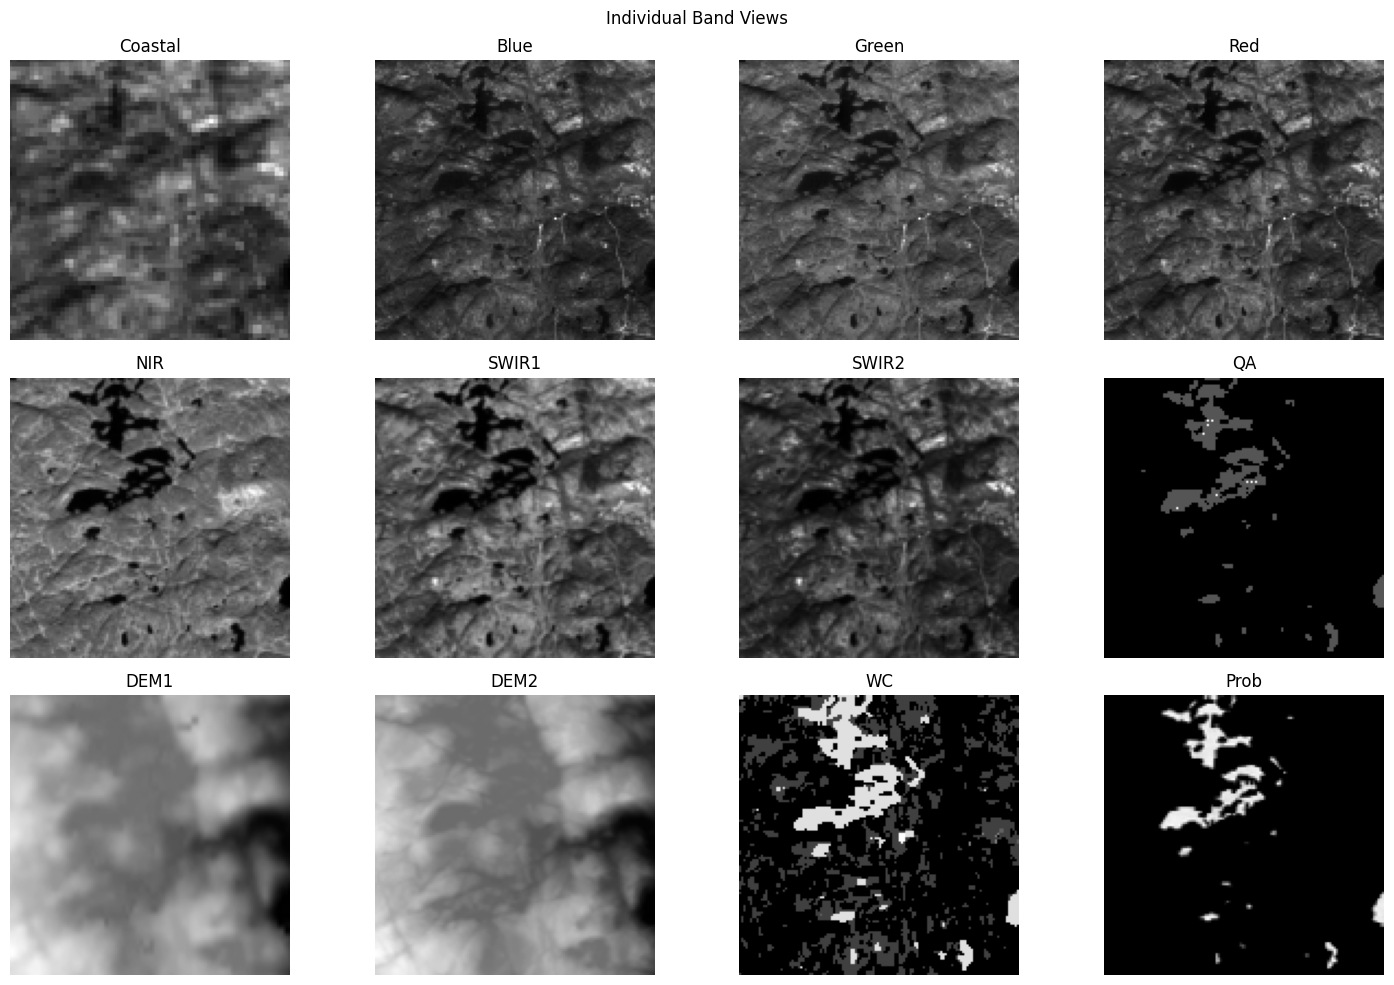

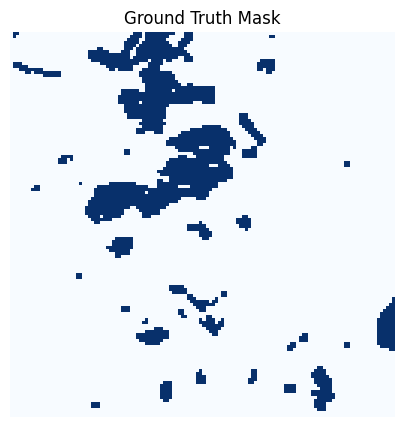

In [10]:
def vis_sample(dataset, idx=0):
    img, mask = dataset[idx]
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    band_names = ['Coastal', 'Blue', 'Green', 'Red', 'NIR', 'SWIR1', 'SWIR2', 'QA', 'DEM1', 'DEM2', 'WC', 'Prob']
    
    for i in range(12):
        ax = axes[i // 4, i % 4]
        ax.imshow(img[i], cmap='gray')
        ax.set_title(band_names[i])
        ax.axis('off')
    
    plt.suptitle('Individual Band Views')
    plt.tight_layout()
    plt.show()
    
    plt.figure(figsize=(5,5))
    plt.imshow(mask[0], cmap='Blues')
    plt.title('Ground Truth Mask')
    plt.axis('off')
    plt.show()

vis_sample(dataset, idx=0)

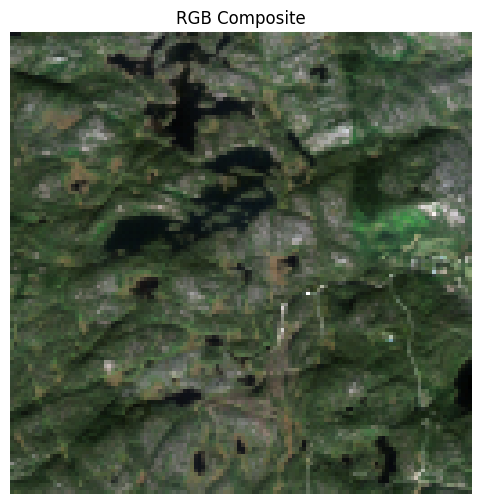

In [11]:
def visualize_rgb(dataset, index=0, r=3, g=2, b=1):
    image, label = dataset[index]
    image = image.numpy()
    label = label.squeeze().numpy()

    rgb = np.stack([image[r], image[g], image[b]], axis=-1)

    plt.figure(figsize=(6,6))
    plt.imshow(rgb)
    plt.title("RGB Composite")
    plt.axis("off")
    plt.show()

visualize_rgb(dataset)